In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

In [91]:
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col = 0, sep = ",", parse_dates=True)
demand_dk = dataframe_dk["DK_load_actual_entsoe_transparency"]
CF_wind = dataframe_dk["wind_cf_Unnamed: 1"]
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"]
dataframe_dk.head()

,DK_load_actual_entsoe_transparency,pv_cf_Unnamed: 1,wind_cf_Unnamed: 1
utc_timestamp,,,
2015-01-01 00:00:00+00:00,3100.00,0.0,0.537323
2015-01-01 01:00:00+00:00,3100.02,0.0,0.557632
2015-01-01 02:00:00+00:00,2980.39,0.0,0.583454
2015-01-01 03:00:00+00:00,2933.49,0.0,0.614832
2015-01-01 04:00:00+00:00,2941.54,0.0,0.644214


In [92]:
data = {

    "capital_cost": [1560000/25, 814000/25, 724000/25],      # $/MW/a
    "marginal_cost": [0.0, 0.0, 61.2]            # $/MWh
}

# Creazione del DataFrame
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])

costs.head()

,capital_cost,marginal_cost
wind_combined,62400.0,0.0
solar,32560.0,0.0
CCGT,28960.0,61.2


Defining Network

In [93]:
dnk_n = pypsa.Network()


In [94]:
dnk_n.set_snapshots(dataframe_dk.index.values)


Adding the first and for now only node/bus ---> Denmark

In [95]:
dnk_n.add("Bus", "Denmark")

Defining carriers (technolgy generators or batteries)

In [96]:
carriers = ["wind_combined", "solar", "CCGT"]
dnk_n.add(
    "Carrier",
    carriers,
    color=["blue","red","brown"],
    )

Demand:

In [97]:
dnk_n.add("Load", "dnk_demand", bus = "Denmark", p_set = demand_dk.values
      )
#Denmark demand associated to the Denmark Bus

In [98]:
max_val = demand_dk.max()
max_time = demand_dk.idxmax()

print(max_val)
print(max_time)

5709.95
2015-01-20 16:00:00+00:00


<Axes: xlabel='snapshot', ylabel='MW'>

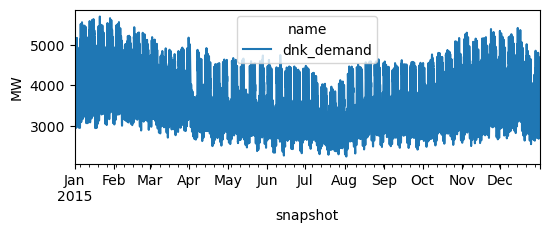

In [99]:
dnk_n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

Generators in Denmark:

In [100]:
# wind onshore
dnk_n.add(
    "Generator",
    "wind_combined", 
    bus = "Denmark", 
    carrier = "wind_combined", 
    capital_cost =  costs.loc["wind_combined", "capital_cost"],
    marginal_cost = costs.loc["wind_combined", "marginal_cost"],
    p_max_pu = CF_wind.values,
    p_nom_extendable = True
    )

In [101]:
# solar
dnk_n.add(
    "Generator",
    "solar", 
    bus = "Denmark", 
    carrier = "solar", 
    capital_cost = costs.loc["solar", "capital_cost"] ,
    marginal_cost = costs.loc["solar", "marginal_cost"],
    p_max_pu = CF_solar.values,
    p_nom_extendable = True
    )

In [102]:
# CCGT
dnk_n.add(
    "Generator",
    "CCGT", 
    bus = "Denmark", 
    carrier = "CCGT", 
    capital_cost = costs.loc["CCGT", "capital_cost"] ,
    marginal_cost = costs.loc["CCGT", "marginal_cost"],
    efficiency = 0.58 ,
    p_nom_extendable = True
    )

<Axes: xlabel='snapshot', ylabel='CF'>

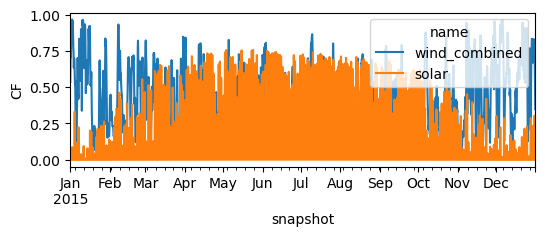

In [103]:
dnk_n.generators_t.p_max_pu.loc["2015"].plot(figsize=(6, 2), ylabel="CF")

Optimize!

In [104]:
dnk_n.optimize(solver_name = "gurobi")

C:\Users\terry\AppData\Local\Temp\ipykernel_5964\3996168487.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<?, ?it/s]
INFO:linopy.io: Writing time: 0.08s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Solved in 1895 iterations and 1.05 seconds (0.36 work units)


INFO:gurobipy:Solved in 1895 iterations and 1.05 seconds (0.36 work units)


Optimal objective  1.269027865e+09


INFO:gurobipy:Optimal objective  1.269027865e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.27e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

Results:

In [105]:
#objective value
print("objective value: ", dnk_n.objective)

objective value:  1269027865.013127


In [106]:
#capacities installed
print("in GW \n", dnk_n.generators.p_nom_opt)

in GW 
 name
wind_combined    8729.050903
solar            3308.106850
CCGT             5271.736256
Name: p_nom_opt, dtype: float64


In [115]:
#hour production for each technology
hourly_prod = dnk_n.generators_t.p
print(hourly_prod)
dnk_n.generators_t.p.to_csv("hourly_dnk_production.csv")



name                 wind_combined  solar        CCGT
snapshot                                             
2015-01-01 00:00:00    3100.000000    0.0    0.000000
2015-01-01 01:00:00    3100.020000    0.0    0.000000
2015-01-01 02:00:00    2980.390000    0.0    0.000000
2015-01-01 03:00:00    2933.490000    0.0    0.000000
2015-01-01 04:00:00    2941.540000    0.0    0.000000
...                            ...    ...         ...
2015-12-31 19:00:00    3687.870000    0.0    0.000000
2015-12-31 20:00:00    3535.550000    0.0    0.000000
2015-12-31 21:00:00    3389.260000    0.0    0.000000
2015-12-31 22:00:00    3091.672707    0.0  170.597293
2015-12-31 23:00:00    3026.702381    0.0  132.147619

[8760 rows x 3 columns]


In [108]:
#annual production for each technology
print(" in TWH \n", dnk_n.generators_t.p.sum()/1e6)


 in TWH 
 name
wind_combined    23.023475
solar             2.209732
CCGT              7.580942
dtype: float64


In [109]:
#hour income for each technology
hourly_income = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy())
print(hourly_income)
dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).to_csv("hourly_dnk_income.csv")


name                 wind_combined  solar          CCGT
snapshot                                               
2015-01-01 00:00:00       0.000000    0.0      0.000000
2015-01-01 01:00:00       0.000000    0.0      0.000000
2015-01-01 02:00:00       0.000000    0.0      0.000000
2015-01-01 03:00:00       0.000000    0.0      0.000000
2015-01-01 04:00:00       0.000000    0.0      0.000000
...                            ...    ...           ...
2015-12-31 19:00:00       0.000000    0.0      0.000000
2015-12-31 20:00:00       0.000000    0.0      0.000000
2015-12-31 21:00:00       0.000000    0.0      0.000000
2015-12-31 22:00:00  189210.369657    0.0  10440.554343
2015-12-31 23:00:00  185234.185714    0.0   8087.434286

[8760 rows x 3 columns]


In [110]:
#annual income for each technology
incomes_y = dnk_n.generators_t.p.multiply(dnk_n.buses_t.marginal_price.to_numpy()).sum()
print(incomes_y)

name
wind_combined    5.446928e+08
solar            1.077120e+08
CCGT             6.166231e+08
dtype: float64


In [111]:
#annual costs for each technology
costs_y = dnk_n.statistics.capex().add(dnk_n.statistics.opex(), fill_value=0)
print(costs_y)

component  carrier      
Generator  CCGT             6.166231e+08
           solar            1.077120e+08
           wind_combined    5.446928e+08
dtype: float64


In [112]:
#hourly energy prices
energy_prices = dnk_n.buses_t.marginal_price
energy_prices.to_csv("annual_energy_prices_dnk.csv")

In [113]:
#annual scarsity revenue, it should be equal to capex cost for each technology
revenue = dnk_n.statistics.revenue(groupby=False)
opex = dnk_n.statistics.opex(groupby=False)


scarsity_revenue = revenue.sub(opex, fill_value=0)

print(scarsity_revenue.loc["Generator"])

print(dnk_n.statistics.capex())

name
CCGT             1.526695e+08
solar            1.077120e+08
wind_combined    5.446928e+08
dtype: float64
component  carrier      
Generator  CCGT             1.526695e+08
           solar            1.077120e+08
           wind_combined    5.446928e+08
dtype: float64
